## Fatbox for numerical modelling – progressive spherical correlation and slip

This tutorial starts slowly with **two outputs**, so that we can see what correlation means. It then applies the same idea automatically to an arbitrary chronological sequence. Finally, it calculates slip for every interval.

Run `tuto_num3_spherical_extraction.ipynb` first. It creates one independent graph for every selected prepared spherical surface archive. No access to the original model directory is required.

### The problem in plain language

Imagine that Fatbox finds nine fault networks in one output and calls them 0–8. In the next output it again starts counting at zero. These numbers are only temporary names: fault 2 at one time is not automatically the same geological structure as fault 2 later.

Correlation compares the geographic shapes and asks: **which earlier fault lies closest to this later fault?** Progressive correlation repeats that question through time and gives continuing structures persistent names.

### What this notebook will do

1. Load all graphs produced by Tutorial 3.
2. Explain correlation using only the first two graphs, `G_0` and `G_1`.
3. Explain the distance threshold `R`.
4. Track persistent fault labels over the complete sequence.
5. Look back two outputs so a temporarily missing fault can recover its identity.
6. Display new, continuing, split and merged fault families.
7. Sample surface velocity and calculate slip for every interval.
8. Save graphs and a readable JSON report.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

fatbox_directory = Path.cwd().resolve()
if not (fatbox_directory / 'modules').is_dir():
    fatbox_directory = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(fatbox_directory / 'modules'))

import spherical_surface
import spherical

### Parameters

The included manifest supplies the same ordered `output_numbers` as Tutorial 3. They do not need to be consecutive, but their model times must increase.

`R` is the largest mean fault distance accepted as a possible match. Here it is in kilometres. A small `R` is strict and may create too many new identities. A large `R` is permissive and may join unrelated structures. Always inspect the correlation matrix and maps.

In [2]:
data_directory = fatbox_directory / 'tutorials' / 'numerical_modelling' / 'data' / 'spherical_example'
manifest = json.loads((data_directory / 'manifest.json').read_text())
output_numbers = tuple(entry['number'] for entry in manifest['outputs'])
R = 300.0                 # correlation distance in km
lookback = 2              # compare with n-1 and n-2
pickup_degrees = 1.0      # velocity samples on each side
direction_cutoff = 2      # graph neighbours used for local strike
results_directory = fatbox_directory / 'tutorial_output' / 'spherical'
figure_directory = results_directory / 'figures'
figure_directory.mkdir(parents=True, exist_ok=True)

if len(output_numbers) < 2:
    raise ValueError('Progressive correlation needs at least two outputs')

### 1. Load the independent graphs

A **record** contains the graph, model time and extraction parameters. A **node** is one point on a skeletonised fault trace. A **fault** is a connected group of nodes. At first, every graph still has its own local labels.

In [3]:
def load_record(output_number):
    path = results_directory / f'G_{output_number:05d}.pickle'
    if not path.is_file():
        raise FileNotFoundError(f'{path} is missing; run Tutorial 3 first')
    with path.open('rb') as stream:
        return pickle.load(stream)

records = [load_record(number) for number in output_numbers]
times_years = np.array([record['time_years'] for record in records])
if not np.all(np.diff(times_years) > 0):
    raise ValueError('output_numbers must be ordered by increasing model time')
raw_graphs = [record['graph'] for record in records]
for number, record in zip(output_numbers, records):
    labels = set(nx.get_node_attributes(record['graph'], 'fault').values())
    print(f'Output {number:05d}: {record["time_years"] / 1e6:.1f} My, {len(labels)} local networks')

Output 00220: 547.5 My, 15 local networks
Output 00221: 550.0 My, 13 local networks
Output 00222: 552.5 My, 12 local networks
Output 00223: 555.0 My, 16 local networks
Output 00224: 557.5 My, 12 local networks
Output 00225: 560.0 My, 12 local networks
Output 00226: 562.5 My, 10 local networks
Output 00227: 565.0 My, 7 local networks
Output 00228: 567.5 My, 7 local networks
Output 00229: 570.0 My, 9 local networks
Output 00230: 572.5 My, 9 local networks


### 2. First understand one pair

We call the first graph `G_0` and the second graph `G_1`, following the existing Fatbox numerical-model tutorials. For each pair of faults, Fatbox measures the mean distance from points in one fault to the nearest points in the other. It calculates both directions because faults can grow or shrink.

In [4]:
G_0, G_1 = raw_graphs[:2]
correlations_01, forward_01, backward_01 = spherical.correlation_slow(
    G_0, G_1, R=R, metric='great_circle'
)
labels_0 = sorted(set(nx.get_node_attributes(G_0, 'fault').values()))
labels_1 = sorted(set(nx.get_node_attributes(G_1, 'fault').values()))
print(f'Possible matches from output {output_numbers[0]} to {output_numbers[1]}:')
sorted(correlations_01)

Possible matches from output 220 to 221:


[(0, 0),
 (1, 1),
 (2, 0),
 (3, 2),
 (4, 3),
 (5, 4),
 (6, 5),
 (7, 6),
 (8, 7),
 (9, 8),
 (10, 9),
 (11, 10),
 (12, 11),
 (13, 2),
 (14, 12)]

The following matrix is a visual check. Dark cells mean similar locations. Red boxes are closer than `R` in at least one direction. One row can contain several red boxes when a fault splits, and one column can contain several when faults merge.

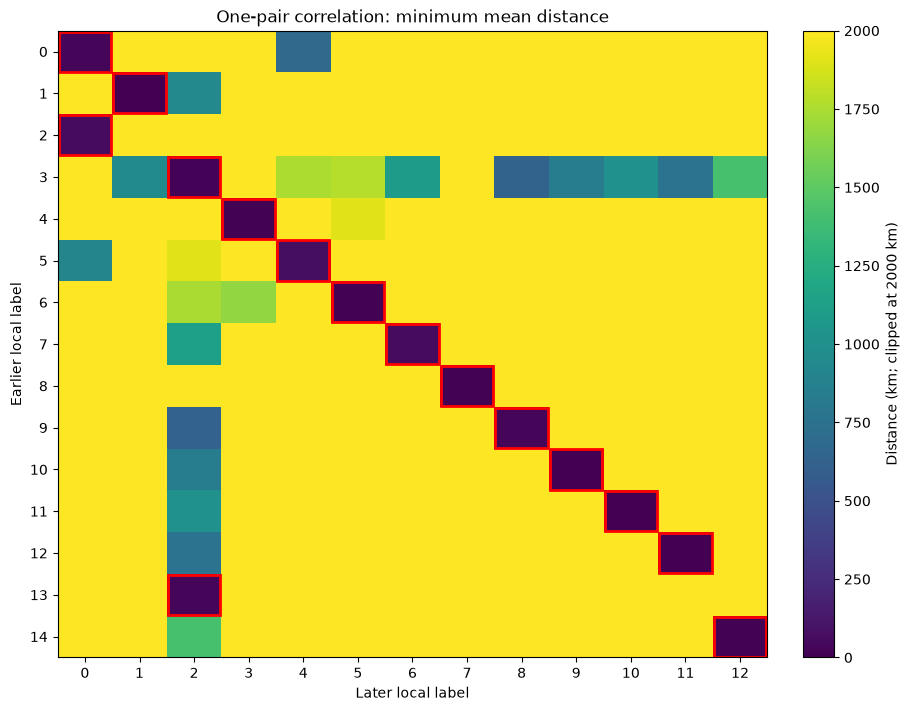

In [5]:
best_01 = np.minimum(forward_01, backward_01.T)
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
image = ax.imshow(np.clip(best_01, 0, 2000), cmap='viridis', aspect='auto')
ax.set(title='One-pair correlation: minimum mean distance', xlabel='Later local label', ylabel='Earlier local label', xticks=range(len(labels_1)), yticks=range(len(labels_0)), xticklabels=labels_1, yticklabels=labels_0)
for i, earlier in enumerate(labels_0):
    for j, later in enumerate(labels_1):
        if (earlier, later) in correlations_01:
            ax.add_patch(plt.Rectangle((j - 0.48, i - 0.48), 0.96, 0.96, fill=False, edgecolor='red', linewidth=2))
fig.colorbar(image, ax=ax, label='Distance (km; clipped at 2000 km)')
fig.savefig(figure_directory / '01_one_pair_correlation.png', dpi=180);

### 3. From one pair to a complete sequence

`track_fault_sequence` repeats the comparison for every ordered graph. It keeps two names on each node:

- `local_fault`: the temporary label produced independently by extraction;
- `fault`: the persistent label followed through time.

A match in either direction makes an earlier identity a possible parent. To choose the primary persistent name, Fatbox uses the better **balanced** match: it minimises the worse of the two directions. This prevents a tiny fragment inside a large network from taking over the large network simply because its one-way distance is zero. All other acceptable parents are stored in `family`, which makes splits and merges visible. Input graphs are copied, not overwritten.

In [6]:
tracked_graphs, tracking_history = spherical.track_fault_sequence(
    raw_graphs, R=R, metric='great_circle', lookback=lookback
)
for number, step in zip(output_numbers, tracking_history):
    print(f'Output {number:05d}: {step["matched"]} matched local networks, {step["new"]} new identities')

Output 00220: 0 matched local networks, 15 new identities
Output 00221: 13 matched local networks, 0 new identities
Output 00222: 12 matched local networks, 0 new identities
Output 00223: 14 matched local networks, 2 new identities
Output 00224: 11 matched local networks, 1 new identities
Output 00225: 12 matched local networks, 0 new identities
Output 00226: 10 matched local networks, 0 new identities
Output 00227: 6 matched local networks, 1 new identities
Output 00228: 7 matched local networks, 0 new identities
Output 00229: 9 matched local networks, 0 new identities
Output 00230: 7 matched local networks, 2 new identities


### 4. Why look back to `n−2`?

A weak structure may disappear from one extracted output and return in the next. With `lookback = 2`, the returning structure is also compared with the graph two outputs earlier. `match_lag = 2` identifies these recoveries. This is the spherical equivalent of Pauline's comparison beyond only `n` and `n+1`.

In [7]:
recoveries = []
for number, graph in zip(output_numbers[1:], tracked_graphs[1:]):
    recovered = sorted({data['fault'] for _, data in graph.nodes(data=True) if data.get('match_lag') == 2})
    if recovered:
        recoveries.append((number, recovered))
print(f'Outputs containing n-2 recoveries: {len(recoveries)}')
recoveries[:10]

Outputs containing n-2 recoveries: 5


[(223, [0, 3, 5]), (225, [3]), (226, [3]), (228, [1, 17]), (229, [8, 18])]

### 5. Inspect persistent labels on maps

We plot the beginning, middle and end of the sequence with the same colour scale. A continuing colour represents the same persistent identity. This visual check is essential: numerical correlation is a hypothesis that must remain geologically sensible.

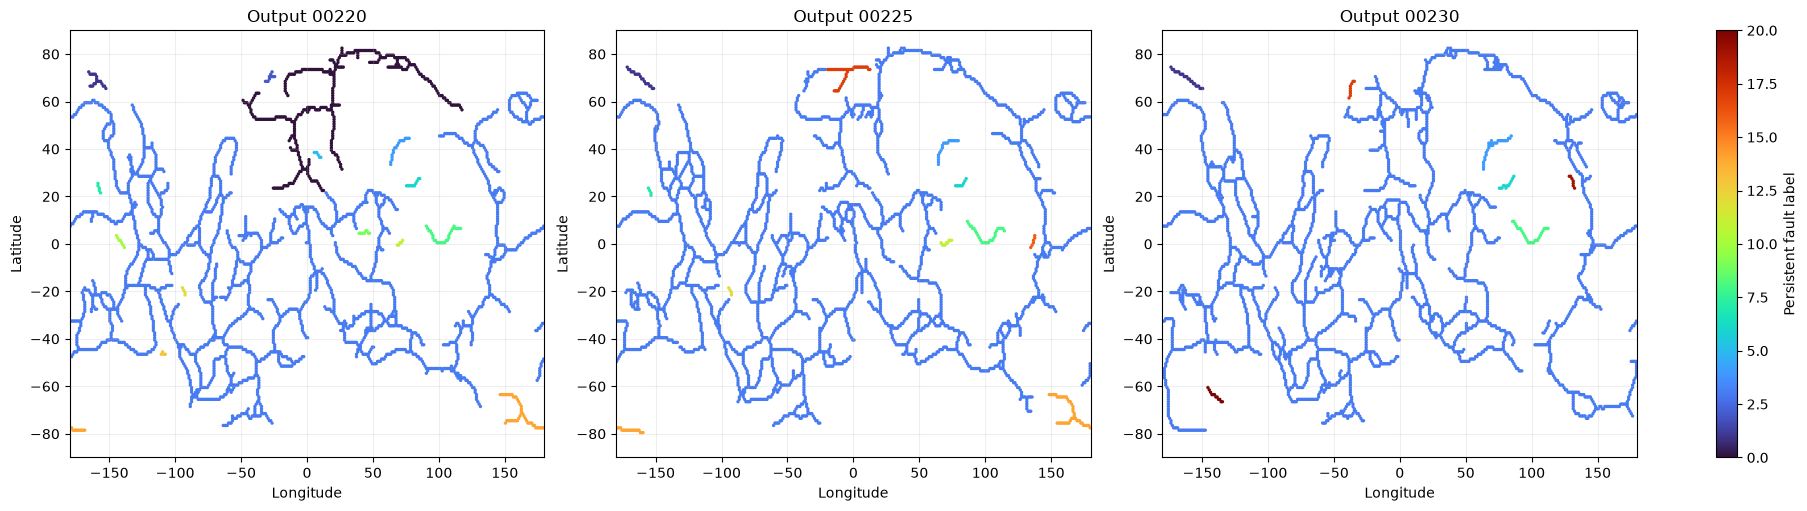

In [8]:
selected_indices = sorted(set((0, len(tracked_graphs) // 2, len(tracked_graphs) - 1)))
maximum_label = max(data['fault'] for graph in tracked_graphs for _, data in graph.nodes(data=True))
fig, axes = plt.subplots(1, len(selected_indices), figsize=(6 * len(selected_indices), 5), constrained_layout=True, squeeze=False)
for ax, index in zip(axes[0], selected_indices):
    graph = tracked_graphs[index]
    positions = nx.get_node_attributes(graph, 'pos')
    scatter = ax.scatter([positions[node][0] for node in graph], [positions[node][1] for node in graph], c=[graph.nodes[node]['fault'] for node in graph], s=2, cmap='turbo', vmin=0, vmax=maximum_label)
    ax.set(title=f'Output {output_numbers[index]:05d}', xlabel='Longitude', ylabel='Latitude', xlim=(-180, 180), ylim=(-90, 90))
    ax.grid(alpha=0.2)
fig.colorbar(scatter, ax=axes[0], label='Persistent fault label')
fig.savefig(figure_directory / '02_persistent_fault_labels.png', dpi=180);

### 6. Plot tracking diagnostics

Blue shows local networks linked to an existing identity; orange shows genuinely new identities. Many new identities at one time can be real, but can also warn that `R` is too strict or extraction changed abruptly.

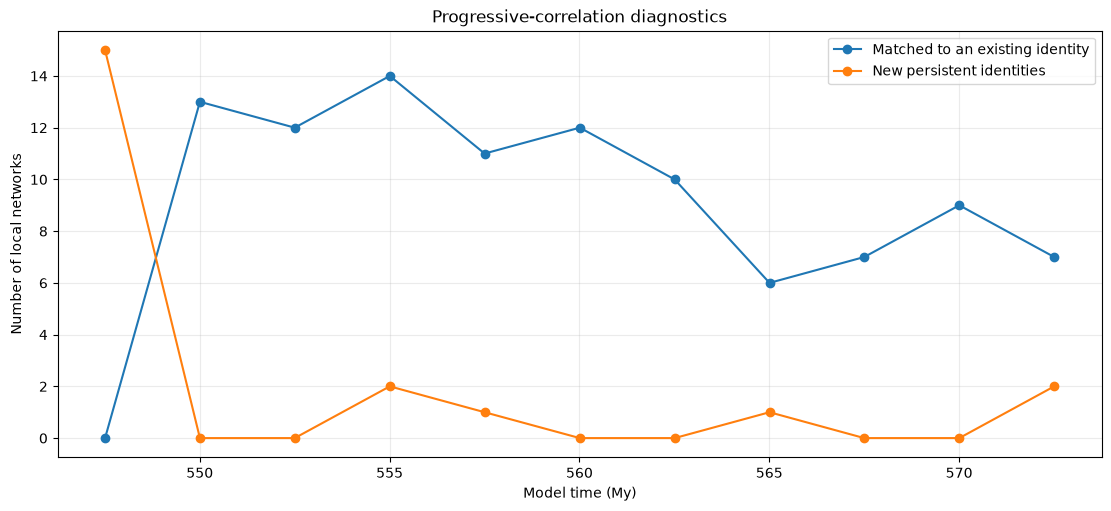

In [9]:
matched_counts = [step['matched'] for step in tracking_history]
new_counts = [step['new'] for step in tracking_history]
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(times_years / 1e6, matched_counts, 'o-', label='Matched to an existing identity')
ax.plot(times_years / 1e6, new_counts, 'o-', label='New persistent identities')
ax.set(title='Progressive-correlation diagnostics', xlabel='Model time (My)', ylabel='Number of local networks')
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(figure_directory / '03_tracking_diagnostics.png', dpi=180);

### 7. Calculate slip for every interval

For interval `n−1 → n`, Fatbox reads the velocity field at output `n`, estimates local fault direction, and places pickup points on both sides of every trace. Their Cartesian velocity difference gives slip rate. Multiplying by the model-time interval gives integrated displacement.

This assumes the later velocity represents the interval. The prepared velocity is metres per year; convert explicitly if your dataset uses other units.

In [10]:
interval_summaries = []
for index in range(1, len(tracked_graphs)):
    number = output_numbers[index]
    graph = tracked_graphs[index]
    surface_file = data_directory / f'spherical_surface_{number:05d}.npz'
    surface = spherical_surface.read_surface_archive(surface_file)
    H = spherical_surface.sample_velocity_difference(graph, surface['velocity'], pickup_degrees, cutoff=direction_cutoff)
    dt_years = times_years[index] - times_years[index - 1]
    spherical.calculate_slip_sphere(graph, H, dt=dt_years, dim=3)
    spherical.write_slip_to_displacement(graph, dim=3)
    rates = np.array([graph.nodes[node]['slip_rate'] for node in graph])
    displacements = np.array([graph.nodes[node]['displacement'] for node in graph])
    assert np.all(np.isfinite(rates))
    interval_summaries.append({
        'from_output': output_numbers[index - 1],
        'to_output': number,
        'dt_years': float(dt_years),
        'finite_slip_rate_fraction': float(np.isfinite(rates).mean()),
        'median_slip_rate_m_per_year': float(np.median(rates)),
        'median_displacement_m': float(np.median(displacements)),
    })
    with (results_directory / f'G_{number:05d}_tracked_kinematics.pickle').open('wb') as stream:
        pickle.dump(graph, stream)
    print(f'{output_numbers[index - 1]:05d} -> {number:05d}: median rate {np.median(rates):.4g} m/year')

00220 -> 00221: median rate 0.007719 m/year


00221 -> 00222: median rate 0.007495 m/year


00222 -> 00223: median rate 0.007341 m/year


00223 -> 00224: median rate 0.007417 m/year


00224 -> 00225: median rate 0.0075 m/year


00225 -> 00226: median rate 0.007271 m/year


00226 -> 00227: median rate 0.007415 m/year


00227 -> 00228: median rate 0.00752 m/year


00228 -> 00229: median rate 0.007784 m/year


00229 -> 00230: median rate 0.007493 m/year


### 8. Inspect the final slip-rate map

The colour scale is capped at the 99th percentile so a few extreme values do not hide the global pattern. Both hemispheres and the dateline must remain populated with finite values.

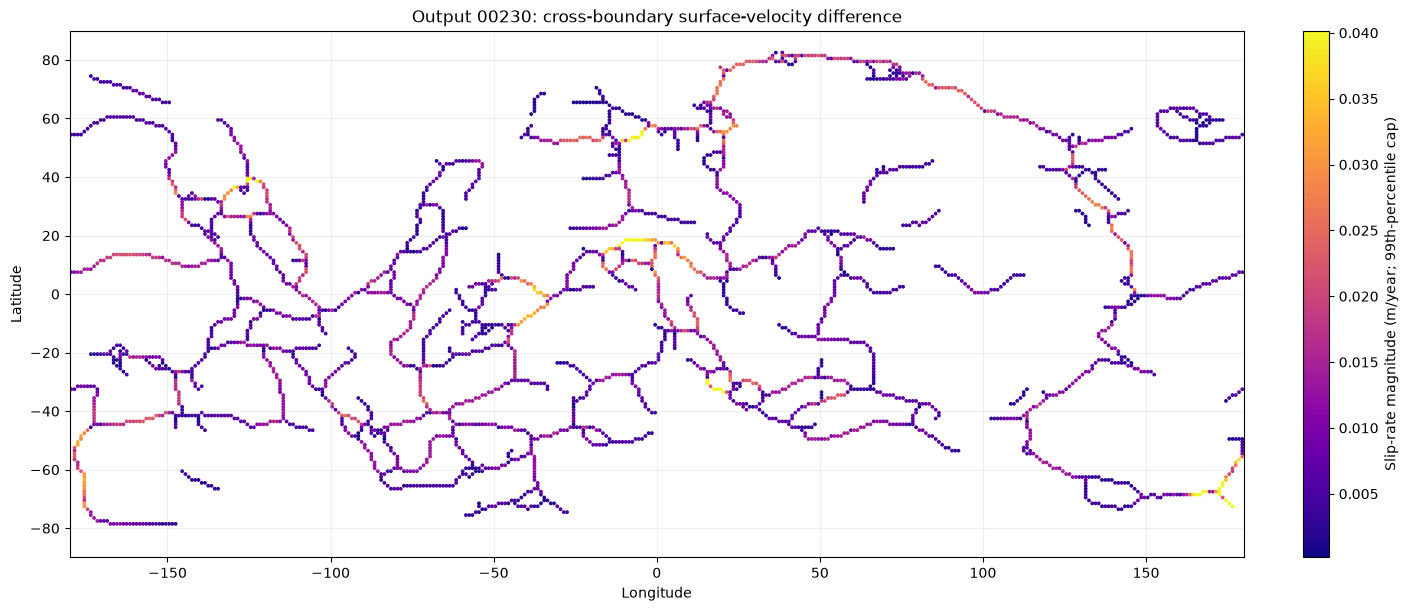

In [11]:
final_graph = tracked_graphs[-1]
final_positions = nx.get_node_attributes(final_graph, 'pos')
final_rates = np.array([final_graph.nodes[node]['slip_rate'] for node in final_graph])
southern_rates = np.array([final_graph.nodes[node]['slip_rate'] for node in final_graph if final_positions[node][1] < 0])
dateline_nodes = [node for node in final_graph if abs(final_positions[node][0]) > 170]
assert len(southern_rates) and np.all(np.isfinite(southern_rates))
assert dateline_nodes and all(np.isfinite(final_graph.nodes[node]['slip_rate']) for node in dateline_nodes)
cap = np.percentile(final_rates, 99)
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
points = ax.scatter([final_positions[node][0] for node in final_graph], [final_positions[node][1] for node in final_graph], c=np.clip(final_rates, 0, cap), s=3, cmap='plasma')
ax.set(title=f'Output {output_numbers[-1]:05d}: cross-boundary surface-velocity difference', xlabel='Longitude', ylabel='Latitude', xlim=(-180, 180), ylim=(-90, 90))
ax.grid(alpha=0.2)
fig.colorbar(points, ax=ax, label='Slip-rate magnitude (m/year; 99th-percentile cap)')
fig.savefig(figure_directory / '04_final_slip_rate.png', dpi=180);

### 9. Save a readable report

Pickle files retain complete NetworkX graphs. JSON is easier to inspect and share, so the report records parameters, label mappings, split/merge families, two-step recoveries and interval kinematics.

In [12]:
report = {
    'output_numbers': list(output_numbers),
    'times_years': times_years.tolist(),
    'correlation_distance_km': R,
    'lookback': lookback,
    'pickup_degrees': pickup_degrees,
    'tracking_history': tracking_history,
    'n_minus_2_recoveries': [[number, labels] for number, labels in recoveries],
    'intervals': interval_summaries,
}
report_path = results_directory / 'spherical_progressive_tracking_report.json'
report_path.write_text(json.dumps(report, indent=2) + '\n')
print('Saved:', report_path.relative_to(fatbox_directory))

Saved: tutorial_output/spherical/spherical_progressive_tracking_report.json


### Summary

You have now followed the complete spherical workflow: independent extraction, one-pair correlation, persistent progressive labels, two-output recovery, split/merge families, and kinematics for every interval.

Correlation is not a substitute for geological judgement. Before analysing fault ages or statistics, inspect the matrices, persistent-label maps, new-label diagnostic and strain-localisation history. Adjust `R`, extraction threshold or output spacing when the matches are not geologically convincing.